## ISSW_Analyze

Definition of the absorption optical depth:
$$
\tau = log({I_0 \over I})
$$

Definition of the absorption Angstrom exponent:
$$
AAE = -{log(\tau_{450}/\tau_{600}) \over log(\lambda_{450}/\lambda_{600})}
$$

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.ndimage import uniform_filter1d
import ISSWlib as IS
import pandas as pd
import os
%matplotlib inline

In [2]:
!pwd
!ls -l UCBoulder/Rainier_2

/home/chemistry/LAI_in_snow/ISSW
total 64
-rw-r--r-- 1 chemistry chemistry 10431 Jul 10 04:24 Blank.txt
-rw-r--r-- 1 chemistry chemistry 10431 Jul 10 04:44 Rainier_muir_06-25-25.txt
-rw-r--r-- 1 chemistry chemistry 10431 Jul 10 04:46 Rainier_muir_07-13-25.txt
-rw-r--r-- 1 chemistry chemistry 10431 Jul 10 04:42 Rainier_summit_06-25-25.txt
-rw-r--r-- 1 chemistry chemistry 10431 Jul 10 04:39 Rainier_summit_08-25-25.txt
-rw-r--r-- 1 chemistry chemistry   110 Jul 16 12:45 spectrum_files.txt


In [3]:
# Choose the spectrum folder and load in the list of spectra there
# spectrum_folder = 'Rainier_and_MtCook_comparison/'
# spectrum_folder = 'UPS_Rainier2025-07-03-01/'; filtertype = 'millipore'
# spectrum_folder = 'UCBoulder/Rainier_1/'; filtertype = 'millipore'
# spectrum_folder = 'UCBoulder/Rainier_2/'; filtertype = 'millipore'
# spectrum_folder = 'UCBoulder/Baker_1/'; filtertype = 'millipore'
# spectrum_folder = 'UCBoulder/Baker_2/'; filtertype = 'millipore'
# spectrum_folder = 'UCBoulder/Adams_1/'; filtertype = 'millipore'
# spectrum_folder = 'UCBoulder/Misc_1/'; filtertype = 'millipore'
spectrum_folder = 'Ulyana ful/'; filtertype = 'millipore'
# spectrum_folder = 'Ponderosa pine pollen/'; filtertype = 'millipore'
# spectrum_folder = 'Rainier dirt/'; filtertype = 'millipore'

# spectrum_folder = 'UPS_2016Chile/'; filtertype = 'nucleopore'
# spectrum_folder = 'NuCStandards/'; filtertype = 'nucleopore'
# spectrum_folder = 'UPS_INKStandards/'; filtertype = 'nucleopore'
# spectrum_folder = '2026July7/NucInc/'; filtertype = 'nucleopore'
# spectrum_folder = '2026July7/NucFul/'; filtertype = 'nucleopore'
# spectrum_folder = 'NuCStandards/'; filtertype = 'nucleopore'

# !ls -l '2026July7'
# !ls -l '2026July7/NucFul'
# !ls -l '2026July7/NucInc'

# Checking location of files
files = os.listdir(spectrum_folder)
print(files)

['66 ug.txt', '5 ug.txt', '10 ug.txt', '40 ug.txt', '.ipynb_checkpoints', 'Blank.txt', '25 ug.txt', '2 ug.txt', 'spectrum_files.txt']


In [4]:
# Parameter file
# parameter_filename = 'calibration parameters from UPS_INKStandards (July 13, 2026).csv'
# parameter_filename = 'calibration parameters from 2026July7 NucFul (July 13, 2026).csv'
parameter_filename = 'calibration III parameters from Ulyana ful (July 21, 2026).csv'
# parameter_filename = 'calibration III parameters from Ink (July 21, 2026).csv'
# parameter_filename = 'calibration parameters from Ulyana ful (July 16, 2026), with iterative adj of AAE.csv'

df = pd.read_csv(parameter_filename)
print(df)
calibration_spectrum_folder = df.at[0, 'calibration_spectrum_folder']
R_450_std = df.at[0,'R_450_std']
R_600_std = df.at[0,'R_600_std']
betabar_450_std = df.at[0,'betabar_450_std']
betabar_600_std = df.at[0,'betabar_600_std']
filtertype_std = df.at[0,'filtertype_std']
AAE_std = df.at[0,'AAE_std']

  calibration_spectrum_folder  R_450_std  R_600_std  betabar_450_std  \
0                 Ulyana ful/       0.99   0.680313         0.255639   

   betabar_600_std filtertype_std   AAE_std  
0         0.296932      millipore -0.520497  


In [5]:
spectrum_filelist = spectrum_folder+'spectrum_files.txt'
spectrum_list, number_of_loadings = IS.get_spectrum_list(spectrum_filelist)

From getline0list: In  Ulyana ful/spectrum_files.txt , finding these spectra:
      2 ug.txt
      5 ug.txt
      10 ug.txt
      25 ug.txt
      40 ug.txt
      66 ug.txt


In [6]:
# Load in the blank, and check indices
lambda_nm, I0_raw = IS.get_spectrum(spectrum_folder+'/Blank.txt')
I_450 = 100; print('lambda_450 = ',lambda_nm[I_450])
I_600 = 250; print('lambda_600 = ',lambda_nm[I_600])
I_1 = I_450
I_2 = I_600

lambda_450 =  450.0
lambda_600 =  600.0


In [7]:
# Preallocate arrays and other constants
chi_observed = np.zeros((number_of_loadings,2))
bot = np.log(lambda_nm[I_1]/lambda_nm[I_2])

chi1, chi2 =  0.36342949339332997 0.29156555320086175
chi1, chi2 =  0.7468878797583914 0.7369637834560532
chi1, chi2 =  1.424818303174949 1.520249907521638
chi1, chi2 =  1.8088481064845767 2.7549986202915435
chi1, chi2 =  1.9800604004714575 3.57853570875876
chi1, chi2 =  1.9789035246186943 3.8350560435704044


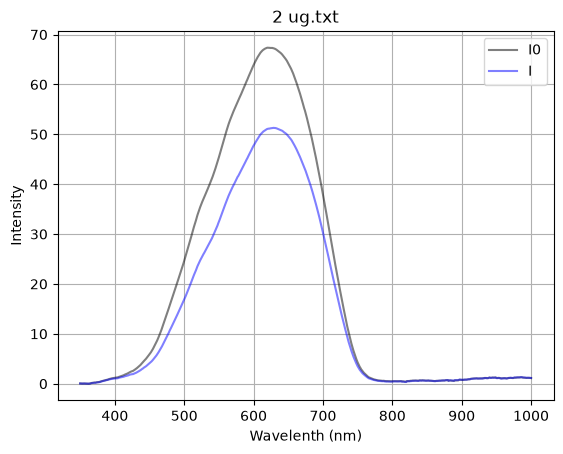

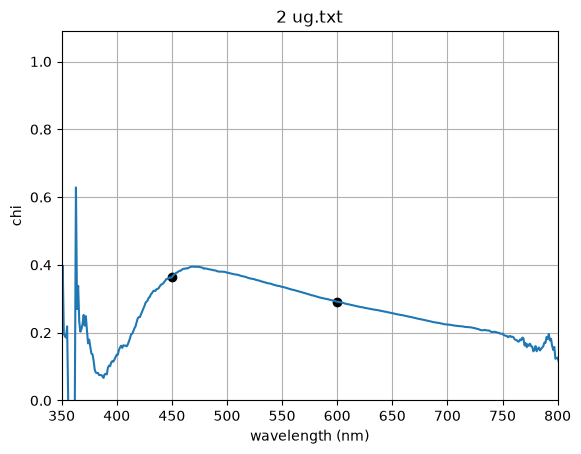

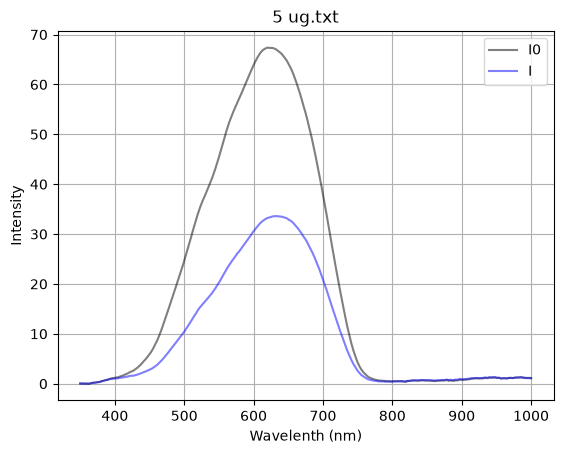

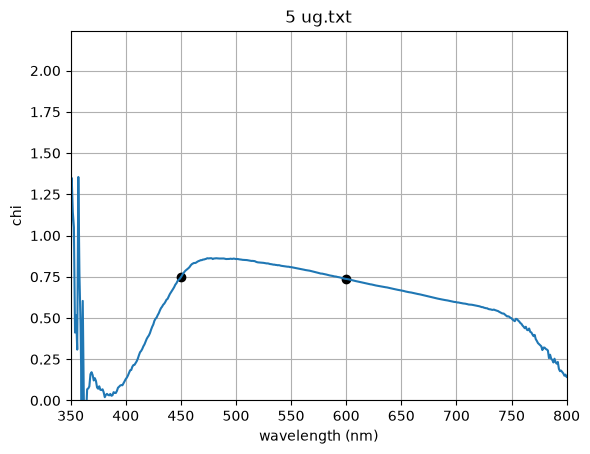

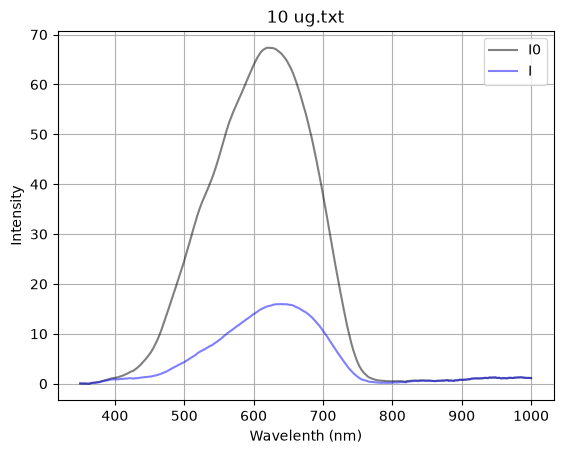

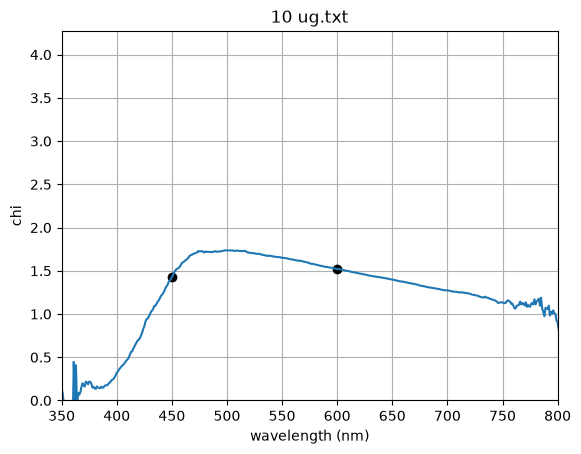

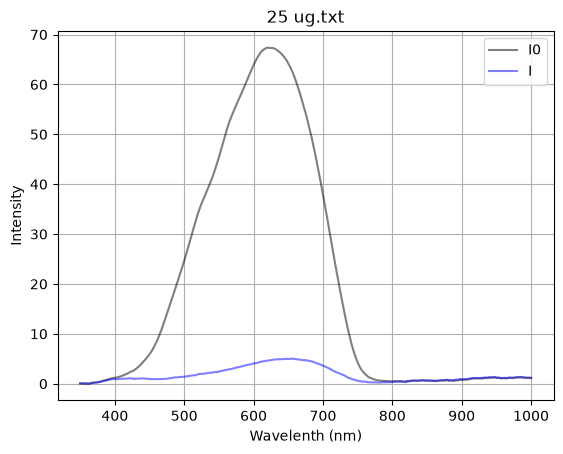

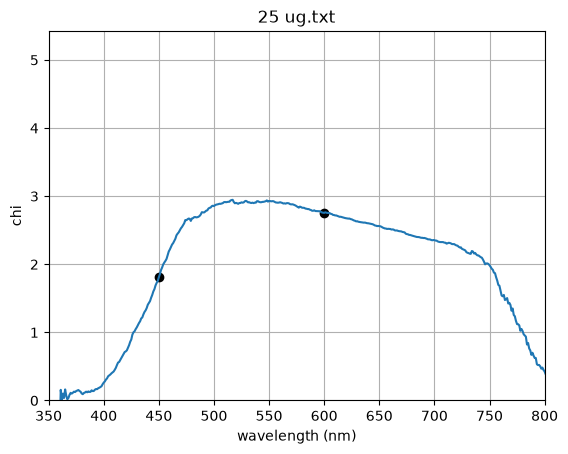

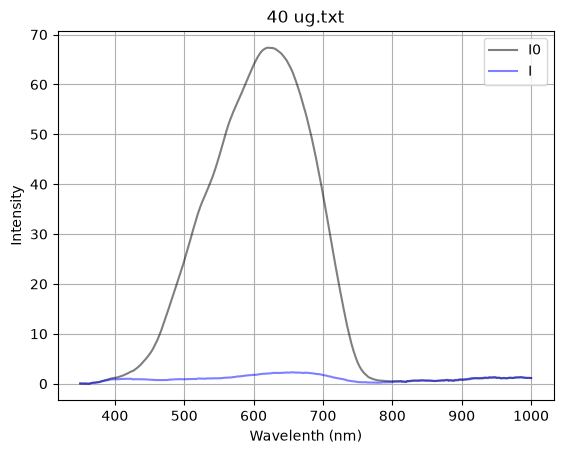

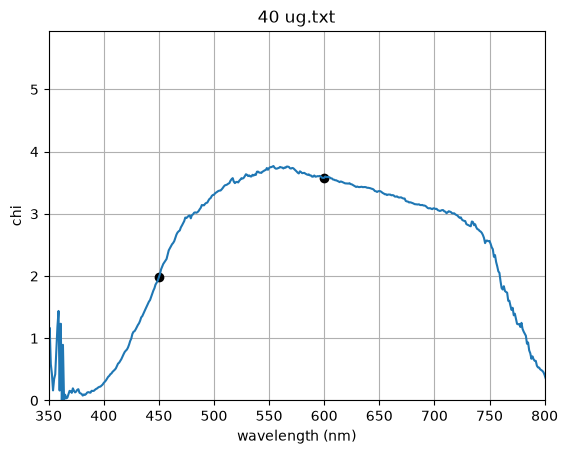

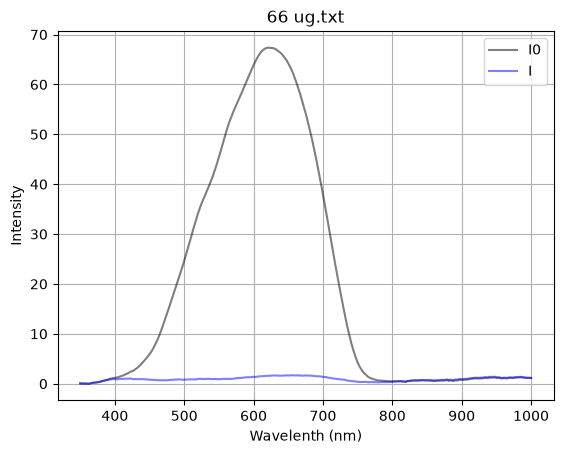

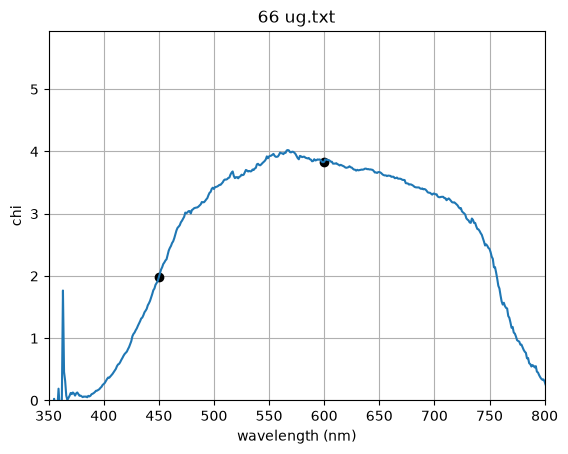

In [8]:
for i in range(number_of_loadings):
    
    # Extract the spectrum for this item in the list
    spectrum_filename = spectrum_list[i]
    lambda_nm, I_raw = IS.get_spectrum(spectrum_folder+spectrum_filename)
    
    # Smooth and shift
    I, I0 = IS.smooth_and_shift(I_raw,I0_raw)
    
    # Get the observed chi-values
    chi = IS.get_chi_obs(I,I0,lambda_nm, title=spectrum_filename)
    print('chi1, chi2 = ', chi[I_1],chi[I_2])
    
    # Save chi values at lambda1 and lambda2
    chi_450_obs = chi[I_1]
    chi_600_obs = chi[I_2]
    
    # Get the tau values associated with these two points
    f_450_obs = IS.get_f(chi_450_obs,R_450_std)
    f_600_obs = IS.get_f(chi_600_obs,R_600_std)
    taubar_450_obs = f_450_obs *2*(1+R_450_std)/(1-R_450_std)
    taubar_600_obs = f_600_obs *2*(1+R_600_std)/(1-R_600_std)

    # Get the Angstrom exponent
    top = np.log(taubar_450_obs/taubar_600_obs)
    AAE = -top/bot
    
    # Record for plotting later
    if i==0:
        AAE_obs_list = AAE
        taubar_450_obs_list = taubar_450_obs
        taubar_600_obs_list = taubar_600_obs
    else:
        AAE_obs_list = np.append(AAE_obs_list,AAE)
        taubar_450_obs_list = np.append(taubar_450_obs_list,taubar_450_obs)
        taubar_600_obs_list = np.append(taubar_600_obs_list,taubar_600_obs)

In [9]:
# Getting equivalent loadings
L_450_equiv = taubar_450_obs_list/betabar_450_std
L_600_equiv = taubar_600_obs_list/betabar_600_std

print(filtertype_std)
if filtertype_std == 'nucleopore' and filtertype == 'millipore':
    print('applying a nucleopore-to-millipore correction')
    filter_factor = 2.55
    L_450_equiv /= filter_factor
    L_600_equiv /= filter_factor
elif filtertype_std == 'millipore' and filtertype == 'nucleopore':
    print('applying a millipore-to- nucleopore correction')
    filter_factor = 2.55
    L_450_equiv *= filter_factor
    L_600_equiv *= filter_factor
    
# Report out
print('450')
for j in range(number_of_loadings):
    print('fullerene-equivalent loading at 450, AAE = ', spectrum_list[j], L_450_equiv[j], AAE_obs_list[j])


millipore
450
fullerene-equivalent loading at 450, AAE =  2 ug.txt 1.7143346578421397 0.9209846363197641
fullerene-equivalent loading at 450, AAE =  5 ug.txt 4.3436287049624625 0.15535253331057897
fullerene-equivalent loading at 450, AAE =  10 ug.txt 12.348840133158943 -0.03133277572693022
fullerene-equivalent loading at 450, AAE =  25 ug.txt 19.959890855479628 -1.8237286709275156
fullerene-equivalent loading at 450, AAE =  40 ug.txt 24.41594177523992 -2.5079209602195447
fullerene-equivalent loading at 450, AAE =  66 ug.txt 24.383203468533452 -2.85697487610857
